In [1]:
!pip install pulser

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.8 MB 10.7 MB/s eta 0:00:01
   --------------------- ------------------ 5.2/9.8 MB 13.3 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 15.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 15.3 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [requests-mock]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
   -------- ------------------------------- 2/9 [qutip]
 


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pulser
from matplotlib import pyplot as plt

In [3]:
device = pulser.AnalogDevice
print(device.specs)

A realistic device for analog sequence execution.

Register parameters:
 - Dimensions: 2D
 - Maximum number of atoms: 80
 - Maximum distance from origin: 38 µm
 - Minimum distance between neighbouring atoms: 5 μm

Layout parameters:
 - Requires layout: Yes
 - Accepts new layout: Yes
 - Minimal number of traps: 1
 - Minimum layout filling fraction: 0.0
 - Maximum layout filling fraction: 0.5

Device parameters:
 - Rydberg level: 60
 - Ising interaction coefficient: 865723.02
 - Channels can be reused: No
 - Supported bases: ground-rydberg
 - Supported states: r, g
 - SLM Mask: No
 - Maximum sequence duration: 6000 ns
 - Maximum number of runs: 2000

Channels:
 - 'rydberg_global': Rydberg(addressing='Global',
        max_abs_detuning=125.66370614359172,
        max_amp=12.566370614359172,
        min_retarget_interval=None,
        fixed_retarget_t=None,
        max_targets=None,
        clock_period=4,
        min_duration=16,
        max_duration=100000000,
        min_avg_amp=0,
     

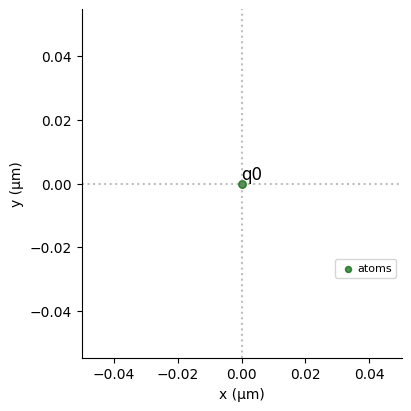

In [4]:
register = pulser.Register.from_coordinates([(0, 0)], prefix="q")
register.draw()

In [6]:
#To check that the created regsiter matched the chosen device 
sequence = pulser.Sequence(register, device)

# Pitch a channel (a laser)
sequence.declare_channel("rydberg_global", "rydberg_global")
print(
    "The states used in the computation are", sequence.get_addressed_states()
)

The states used in the computation are ['r', 'g']


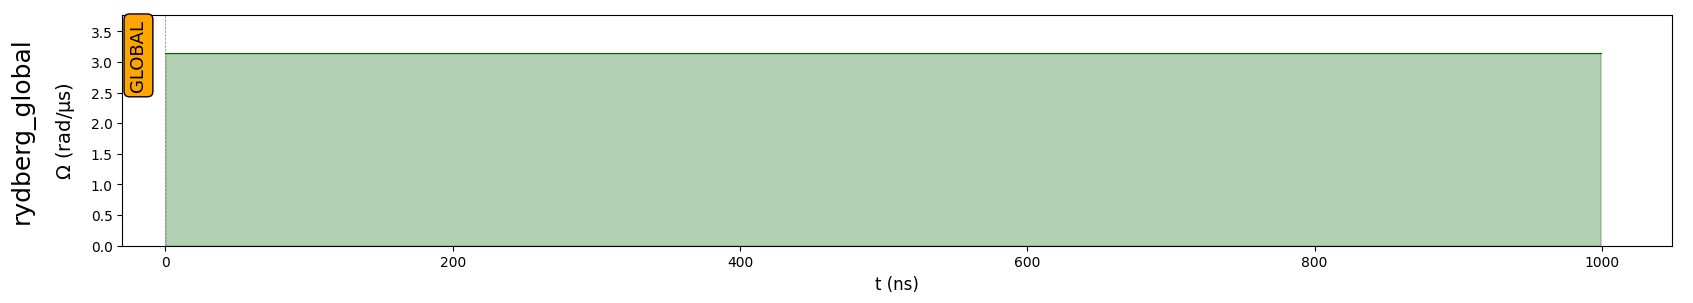

In [7]:
pi_pulse = pulser.Pulse.ConstantPulse(1000, np.pi, 0, 0)
sequence.add(pi_pulse, "rydberg_global")
sequence.draw(mode='input')

In [8]:
backend = pulser.backends.QutipBackendV2(sequence)
result = backend.run()

In [10]:
result.final_bitstrings

Counter({'1': 1000})

In [15]:
# Tutorial Programming with Pulser
# Partie 2 - 9 atomes en état antiferromagnetique

# Parameters in rad/µs
U = 2 * np.pi
Omega_max = 2.0 * U
delta_0 = -6 * U
delta_f = 2 * U

# Parameters in ns
t_rise = 252
t_fall = 500
t_sweep = (delta_f - delta_0) / (2 * np.pi * 10) * 1000

device = pulser.AnalogDevice
# print(device.specs)

Interatomic Radius is: 7.186760677748386µm.


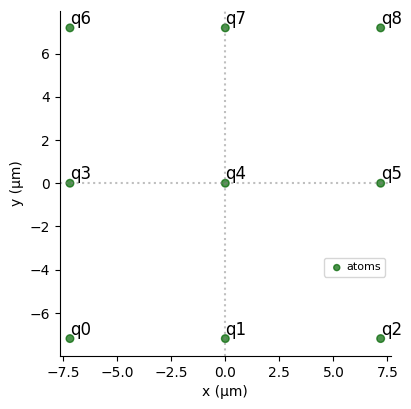

In [17]:
R_interatomic = (device.interaction_coeff / U) ** (1 / 6)
N_side = 3
register = pulser.Register.square(N_side, R_interatomic, prefix="q")
print(f"Interatomic Radius is: {R_interatomic}µm.")
register.draw()

In [19]:
sequence = pulser.Sequence(register, device)
sequence.declare_channel("rydberg_global", "rydberg_global")
print(
    "The states used in the computatino are", sequence.get_addressed_states()
)

The states used in the computatino are ['r', 'g']


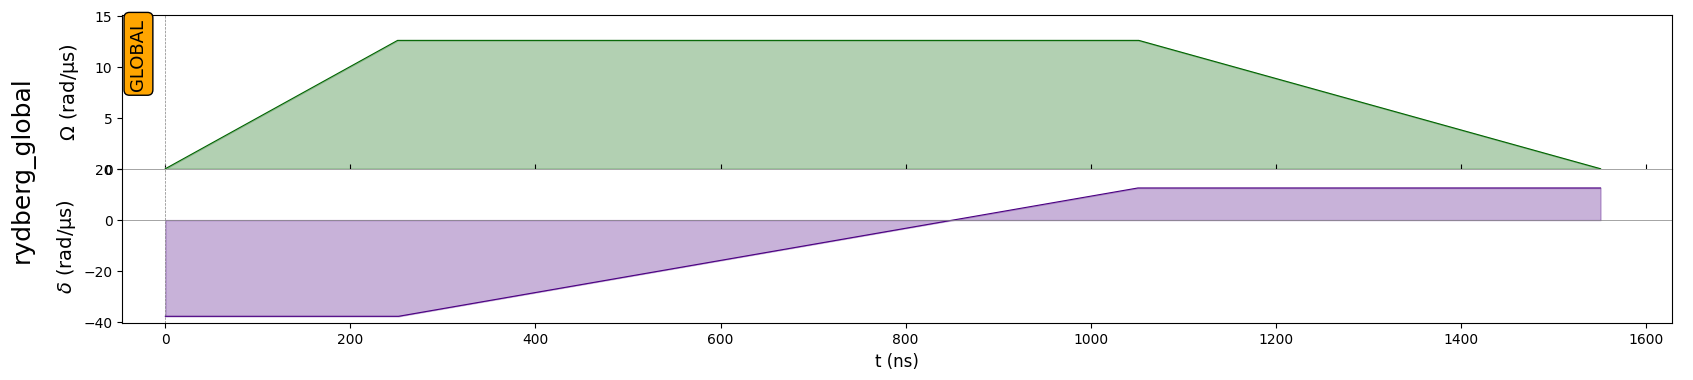

In [22]:
rise = pulser.Pulse.ConstantDetuning(
    pulser.RampWaveform(t_rise, 0.0, Omega_max), delta_0, 0.0
)

sweep = pulser.Pulse.ConstantAmplitude(
    Omega_max, pulser.RampWaveform(t_sweep, delta_0, delta_f), 0.0
)

fall = pulser.Pulse.ConstantDetuning(
    pulser.RampWaveform(t_fall, Omega_max, 0.0), delta_f, 0.0
)

sequence.add(rise, "rydberg_global")
sequence.add(sweep, "rydberg_global")
sequence.add(fall, "rydberg_global")
sequence.draw(mode="input")

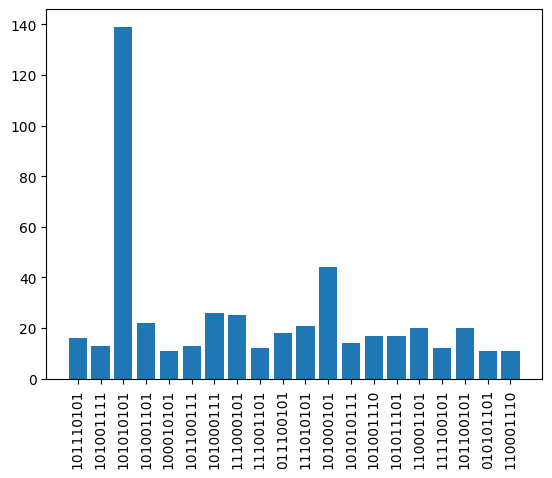

In [24]:
backend = pulser.backends.QutipBackendV2(sequence)
result = backend.run()
counts = result.final_bitstrings

most_freq = {k: v for k, v in counts.items() if v > 10}
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()

In [26]:
#Visualising the Rydberg blocade radius

import pulser

omega = 1 # rad/µs
rb = pulser.AnalogDevice.rydberg_blockade_radius(omega)
print(f"Rydberg blockade radius for Ω={omega} rad/μs: {rb} μm")

print("-"*50)
#Rabi frequence from blocakde radius
rb = 8
omega = pulser.AnalogDevice.rabi_from_blockade(rb) # rad/µs
print(f"Rydberg blockade radius for Ω={omega} rad/μs: {rb} μm")


Rydberg blockade radius for Ω=1 rad/μs: 9.762547522425425 μm
--------------------------------------------------
Rydberg blockade radius for Ω=3.3024712371826173 rad/μs: 8 μm


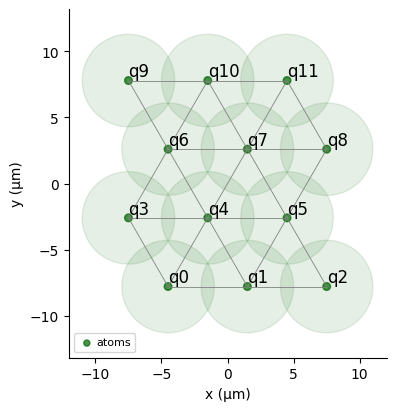

In [27]:
from pulser import Register

tri_reg = Register.triangular_lattice(
    rows=4, atoms_per_row=3, spacing=6.0, prefix="q"
)

tri_reg.draw(
    blockade_radius=7,
    draw_half_radius=True,
    draw_graph=True
)

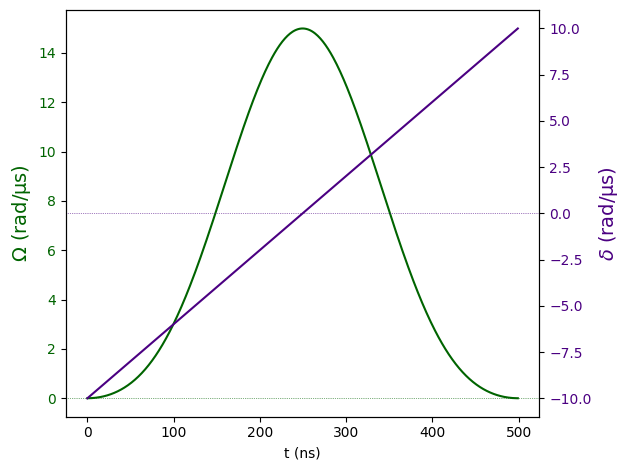

In [28]:
import numpy as np
import pulser

pulse = pulser.Pulse(
    amplitude = pulser.BlackmanWaveform(500, np.pi),
    detuning=pulser.RampWaveform(500, -10, 10),
    phase = np.pi / 2
)
pulse.draw()

Channel: rydberg_global
t: 0 | Initial targets: q0 | Phase Reference: 0.0 
t: 0->1000 | Pulse(Amp=3.14 rad/µs, Detuning=0 rad/µs, Phase=0) | Targets: q0




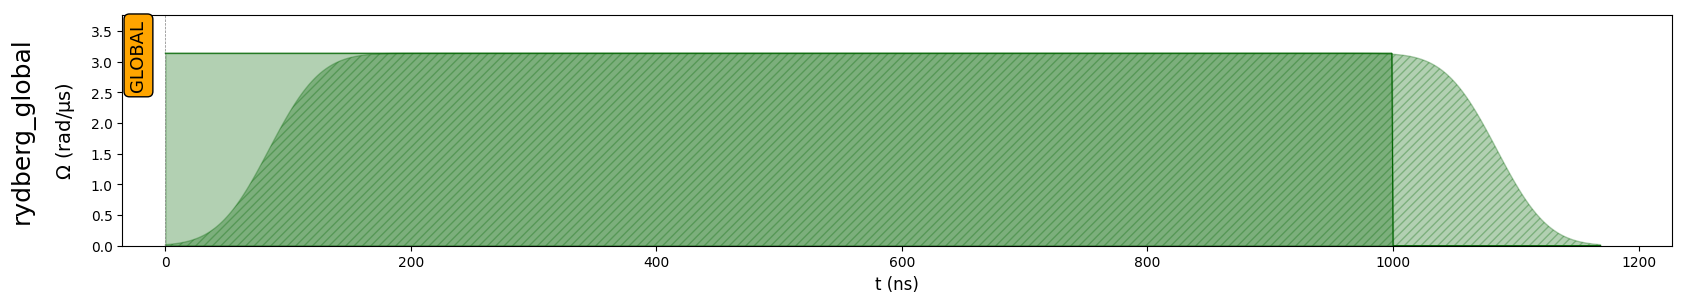

In [2]:
### Sequence Creation and Validation

import pulser

sequence = pulser.Sequence(
    pulser.Register({"q0": (0,0)}), pulser.AnalogDevice
)

sequence.declare_channel("rydberg_global", "rydberg_global")
pulse = pulser.Pulse.ConstantPulse(1000, 3.14, 0, 0)
sequence.add(pulse, "rydberg_global")

print(sequence)
sequence.draw()

In [3]:
import pulser

spacing = 2
reg = pulser.Register({"q0": (0,0), "q1": (spacing, 0)})

assert spacing < pulser.AnalogDevice.min_atom_distance

try:
    pulser.Sequence(reg, pulser.AnalogDevice)
except ValueError as e:
    print("Failed with error: ", e)

Failed with error:  The minimal distance between atoms in this device (5 µm) is not respected (up to a precision of 1e-6 µm) for the pairs: [('q0', 'q1')]


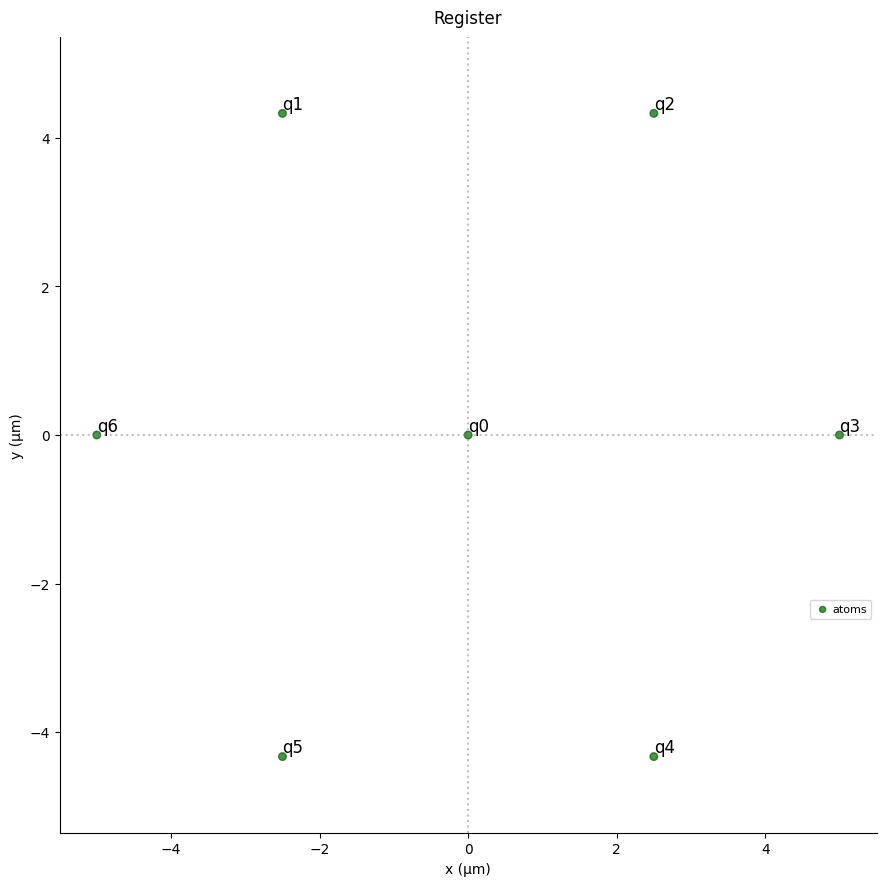

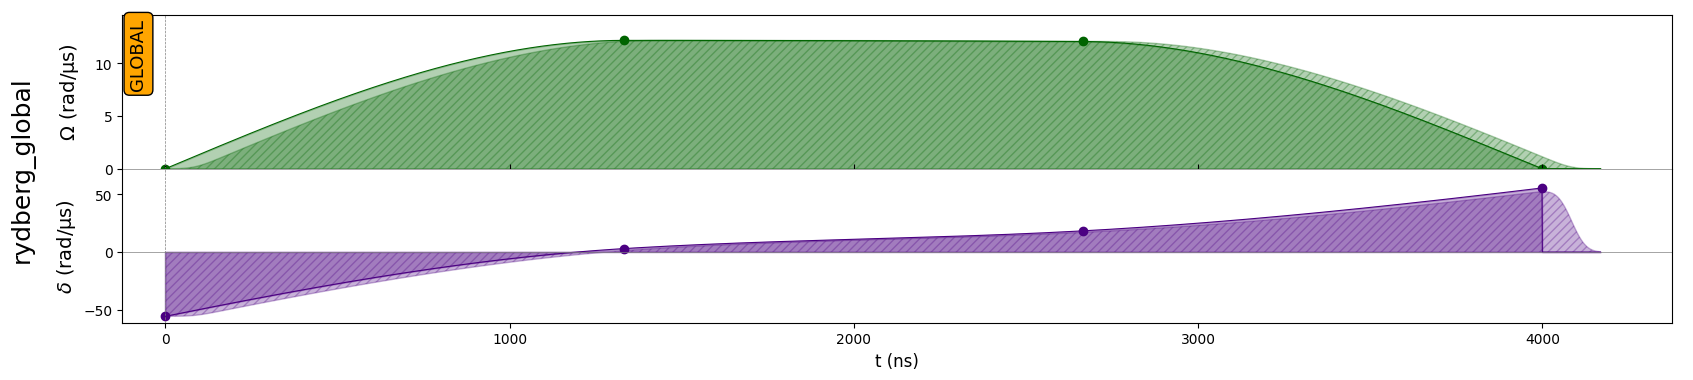

In [4]:
### Execution on an Emulator
# AFM on 7 atom hexagon

import numpy as np
import pulser
import pulser_simulation

device = pulser.AnalogDevice

R_interatomic = 5
register = pulser.Register.hexagon(1, R_interatomic, prefix="q")

seq = pulser.Sequence(register, device)

seq.declare_channel("rydberg_global", "rydberg_global")

U = device.interaction_coeff / R_interatomic ** 6

total_duration = 4000 # ns
interp_pts = np.linspace(0, 1, 4) #Between 0 and 1

seq.add(
    pulser.Pulse(
        pulser.InterpolatedWaveform(
            total_duration,
            U * np.array([1e-9, 0.22, 0.2181, 1e-9]),
            times = interp_pts,
        ),
        pulser.InterpolatedWaveform(
            total_duration,
            U * np.array([-1, 0.0556, 0.332, 1]),
            times = interp_pts,
        ),
        0,
    ),
    "rydberg_global",
)

seq.draw(draw_register=True)

In [7]:
qutip_bknd = pulser.backends.QutipBackendV2(seq)
print(pulser.backends.QutipBackendV2.default_config)

QutipConfig(
    callbacks=(),
    observables=(bitstrings:6452d79e-a449-456f-96b0-e287148e4ddf, state:d3947286-ec6e-4afc-a147-3712d4eca294),
    default_evaluation_times=array([1.]),
    initial_state=None,
    with_modulation=False,
    interaction_matrix=None,
    prefer_device_noise_model=False,
    noise_model=NoiseModel(noise_types=()),
    n_trajectories=1,
    sampling_rate=1.0,
    solver=<Solver.DEFAULT: 'default'>,
    print_progress=False,
    progress_bar=False,
    default_num_shots=1000,
)


In [10]:
qutip_results = qutip_bknd.run()
print(qutip_results)

Results
-------
Stored results: ['bitstrings', 'state']
Evaluation times per result: {'bitstrings': [1.0], 'state': [1.0]}
Atom order in states and bitstrings: ('q0', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6')
Total sequence duration: 4000 ns


In [11]:
print(qutip_results.final_bitstrings)

Counter({'0101010': 515, '0010101': 485})


In [12]:
qutip_state = qutip_results.final_state

qutip_state.to_qobj()

Quantum object: dims=[[2, 2, 2, 2, 2, 2, 2], [1]], shape=(128, 1), type='ket', dtype=Dense
Qobj data =
[[-1.75604005e-04-1.29489143e-04j]
 [-4.46817263e-08-1.96807070e-08j]
 [-4.46817263e-08-1.96807070e-08j]
 [-1.27430212e-08+1.03008645e-08j]
 [-4.46817263e-08-1.96807070e-08j]
 [-1.27727696e-07+3.81966070e-07j]
 [-1.27430212e-08+1.03008645e-08j]
 [-6.76578617e-08-6.93125258e-08j]
 [-4.46817263e-08-1.96807070e-08j]
 [-7.29720059e-09-5.14138075e-08j]
 [-1.27727696e-07+3.81966070e-07j]
 [-3.49424311e-07-2.92799832e-07j]
 [-1.27430212e-08+1.03008645e-08j]
 [-3.49424311e-07-2.92799832e-07j]
 [-6.76578617e-08-6.93125258e-08j]
 [ 1.29651121e-06+4.01192402e-06j]
 [-4.46817263e-08-1.96807070e-08j]
 [-1.27727696e-07+3.81966070e-07j]
 [-7.29720059e-09-5.14138075e-08j]
 [-3.49424311e-07-2.92799832e-07j]
 [-1.27727696e-07+3.81966070e-07j]
 [ 3.65159870e-04+1.50672415e-04j]
 [-3.49424311e-07-2.92799832e-07j]
 [-9.19669984e-05+5.92850912e-05j]
 [-1.27430212e-08+1.03008645e-08j]
 [-3.49424311e-07-2.92

In [13]:
print("Stored results' tags:", qutip_results.get_result_tags())
print(
    "Evaluation times for 'bitstrings':",
    qutip_results.get_result_times("bitstrings"),
)

print("*" * 50)

qutip_results.get_result("bitstrings", 1.0)
qutip_results.bitstrings[-1]

Stored results' tags: ['bitstrings', 'state']
Evaluation times for 'bitstrings': [1.0]
**************************************************


Counter({'0101010': 515, '0010101': 485})

In [ ]:
# It saved only the final state anyway
all_states = qutip_results.state

for t, state_at_t in zip(qutip_results.get_result_times("state"), all_states):
    print(f"-- Etat au temps t = {t}")
    print(state_at_t.to_qobj())

In [26]:
### QPU Execution
# J'ai pas fait le cloud, mais j'essaie les sequences paramétrisée
import numpy as np
import pulser
import pulser_simulation

R_interatomic = 5
register = pulser.Register.hexagon(1, R_interatomic, prefix="q")


param_seq = pulser.Sequence(register, device)
param_seq.declare_channel("rydberg_global", "rydberg_global")

t = param_seq.declare_variable("t", dtype = int)
interp_pts = np.linspace(0, 1, 4) #Between 0 and 1

param_seq.add(
    pulser.Pulse(
        pulser.InterpolatedWaveform(
            t, U * np.array([1e-9, 0.22, 0.2181, 1e-9]), times = interp_pts  
        ),
        pulser.InterpolatedWaveform(
            t, U * np.array([-1, 0.0556, 0.332, 1]), times = interp_pts  
        ),
        0,
    ),
    "rydberg_global"
)

print(param_seq)

Prelude
-------
Channel: rydberg_global
t: 0 | Initial targets: q0, q1, q2, q3, q4, q5, q6 | Phase Reference: 0.0 

Stored calls
------------

1. add(Pulse(InterpolatedWaveform(t[0], [5.54062733e-08 1.21893801e+01 1.20841082e+01 5.54062733e-08], times=[0.         0.33333333 0.66666667 1.        ]), InterpolatedWaveform(t[0], [-55.40627328   3.08058879  18.39488273  55.40627328], times=[0.         0.33333333 0.66666667 1.        ]), 0), rydberg_global)


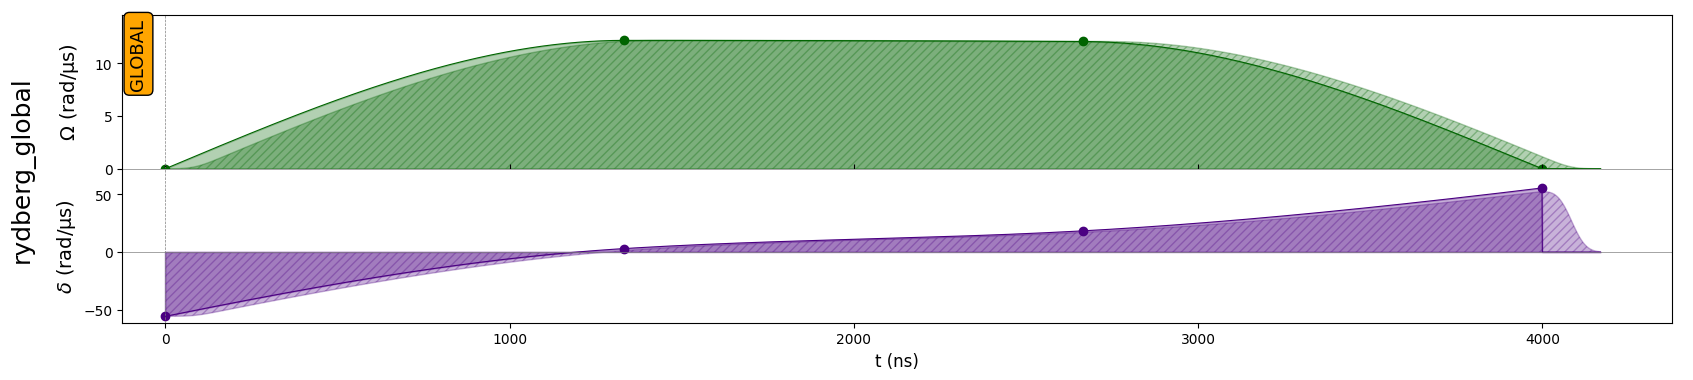

In [27]:
seq_4000 = param_seq.build(t=4000)
seq_4000.draw()

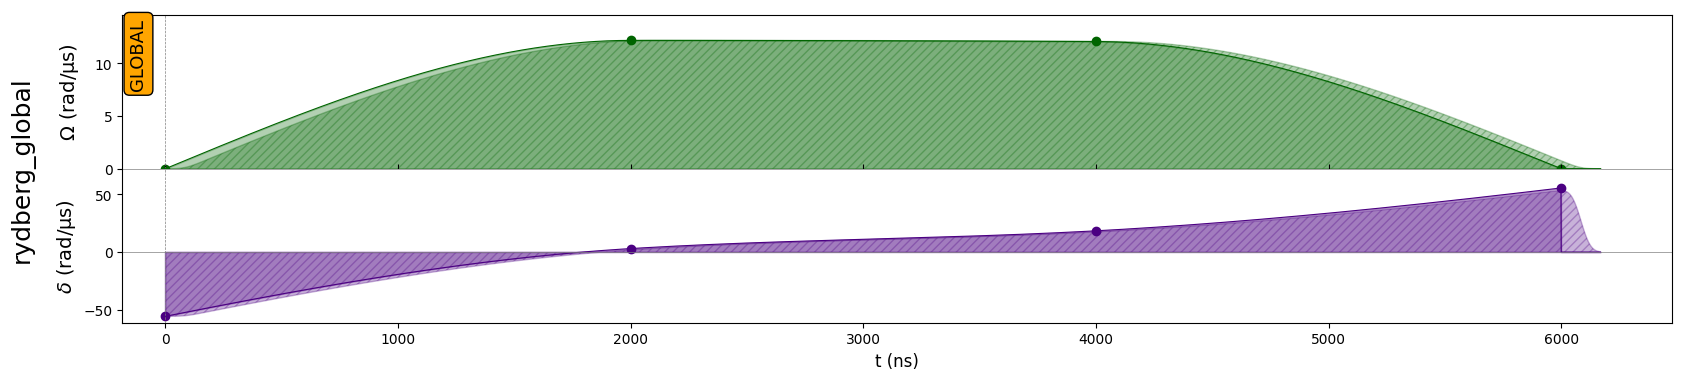

In [28]:
seq_4000 = param_seq.build(t=6000)
seq_4000.draw()

In [ ]:
# Run batched parametrized sequences
param_backend = pulser_simulation.QutipBackendV2(param_seq)
param_job_params = [
    {"variables": {"t":300}},
    {"runs": 1000, "variables": {"t":1000}},
    {"variables": {"t":4000}},
]

param_results = param_backend.run(job_params=param_job_params)

### CE NEST PAS POSSIBLE AVEC UN EMULATEUR LOCAL!!!

ValueError: The provided sequence needs to be built to be simulated. Call `Sequence.build()` with the necessary parameters.

In [ ]:
### Results and Observables

# Choisir quoi et quand mesurer lors de la simu - ce ne peut pas être fait sur la vrai machine, car observer l'état quantitque le fait collapser

## Snippet to Measure Energy at beginning, half-way and at the end
from pulser.backend import BitStrings, Energy, EmulationConfig

config = EmulationConfig(
    default_evaluation_times=[
        1.0
    ],
    observables=[
        BitStrings(),
        Energy(
            evaluation_times=[0.0, 0.5, 1.0]
        ),

    ]
)

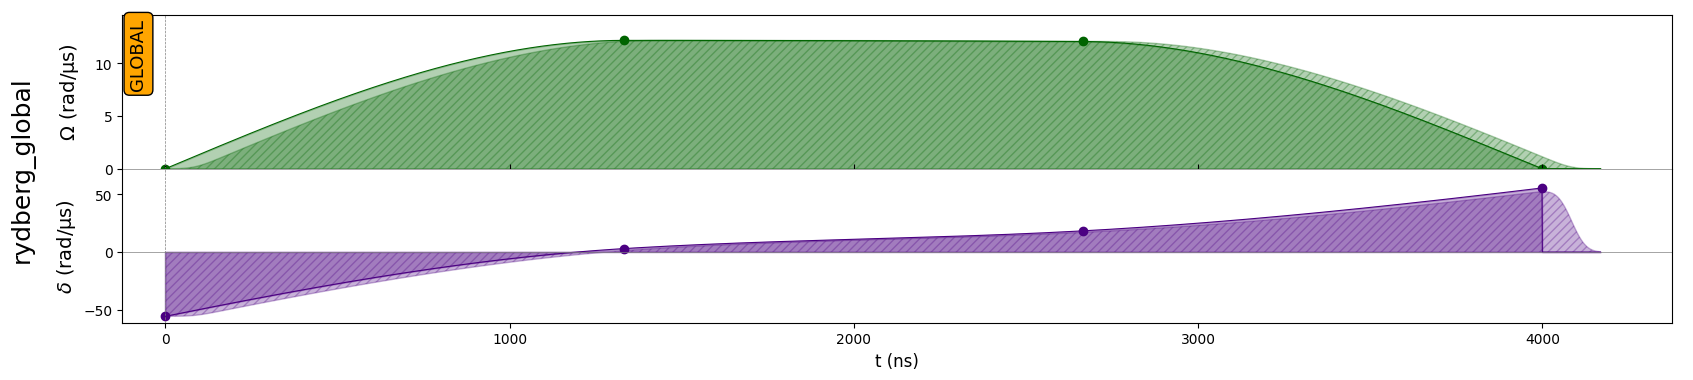

In [43]:
# Approche backend agnostique
# Fidelity - Permet de comparer un état simulé à un état pur théorique à un moment de la simulation
import pulser_simulation
from pulser.backend import Expectation, Fidelity, StateResult

emu_backend_class = pulser_simulation.QutipBackendV2

config_class = emu_backend_class.config_type
state_class = config_class.state_type
operator_class = config_class.operator_type

# Arbitrarily chosen |rr> as state to compare againts in orfer to compute fidelity
r_state = state_class.from_state_amplitudes(
    eigenstates=("r", "g"),
    amplitudes={"rr": 1.0},
)

fidelity = Fidelity(r_state, tag_suffix="rr")

# Arbitrarily chose the operator XX (where X = |r><g| + |g><r|)
pauli_x = operator_class.from_operator_repr(
    eigenstates=("r","g"),
    n_qudits=2,
    operations=[(1.0, [({"rg":1.0, "gr":1.0}, {0, 1})])]
)

expectation = Expectation(
    pauli_x,
    evaluation_times=[0.0, 0.25, 0.5, 0.75, 1.0],
    tag_suffix="XX"
)

state = StateResult()


config = config_class(observables=[fidelity, expectation, state],)


R_interatomic = 5
positions = {
    "q0" : (0, 0),
    "q1" : (R_interatomic, 0)
}
register = pulser.Register(positions)

seq = pulser.Sequence(register, device)

seq.declare_channel("rydberg_global", "rydberg_global")

U = device.interaction_coeff / R_interatomic ** 6

total_duration = 4000 # ns
interp_pts = np.linspace(0, 1, 4) #Between 0 and 1

seq.add(
    pulser.Pulse(
        pulser.InterpolatedWaveform(
            total_duration,
            U * np.array([1e-9, 0.22, 0.2181, 1e-9]),
            times = interp_pts,
        ),
        pulser.InterpolatedWaveform(
            total_duration,
            U * np.array([-1, 0.0556, 0.332, 1]),
            times = interp_pts,
        ),
        0,
    ),
    "rydberg_global",
)

seq.draw()

emu_backend = emu_backend_class(seq, config=config)
results = emu_backend.run()


In [44]:
# Il contient des données pour chaque observable défini
print(results)

Results
-------
Stored results: ['expectation_XX', 'fidelity_rr', 'state']
Evaluation times per result: {'expectation_XX': [0.0, 0.25, 0.5, 0.75, 1.0], 'fidelity_rr': [1.0], 'state': [1.0]}
Atom order in states and bitstrings: ('q0', 'q1')
Total sequence duration: 4000 ns


In [45]:
results.get_tagged_results()

{'expectation_XX': [0.0,
  0.4593990203205929,
  0.9120773311054713,
  0.9983076259277917,
  0.9396544786145703],
 'fidelity_rr': [0.05994734064834717],
 'state': [QutipState
  ----------
  Eigenstates: ('r', 'g')
  Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
  Qobj data =
  [[ 0.10720828+0.22012207j]
   [-0.28885141-0.62175792j]
   [-0.28885141-0.62175792j]
   [ 0.0032491 -0.00244929j]]]}

In [41]:
print("fidelity_rr")
results.get_tagged_results()["fidelity_rr"]

fidelity_rr


[0.05994734064834717]

In [40]:
print("expectation_XX")
results.get_tagged_results()["expectation_XX"]

expectation_XX


[0.0,
 0.4593990203205929,
 0.9120773311054713,
 0.9983076259277917,
 0.9396544786145703]

In [46]:
results.final_state

QutipState
----------
Eigenstates: ('r', 'g')
Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.10720828+0.22012207j]
 [-0.28885141-0.62175792j]
 [-0.28885141-0.62175792j]
 [ 0.0032491 -0.00244929j]]